In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import sparse, linalg
from scipy.io import loadmat,savemat
from math import factorial

from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture # jaxxx??? # Hyakkk
from sklearn.decomposition import SparsePCA
# from scipy.io import loadmat
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import matplotlib.colors as colors

# Seaborn colormap
import seaborn as sns
import colorcet as cc
sns_list = sns.color_palette(cc.glasbey,n_colors=20).as_hex()
sns_list.pop(4)

# sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)
cm = sns_cmap

sns_list_balance_models = sns_list.copy()

sns_list_balance_models.insert(0, '#ffffff')  # Insert white at zero position
sns_list_balance_models.pop(1)
sns_cmap_balance_models = ListedColormap(sns_list_balance_models)

cm_balance_models = sns_cmap_balance_models
  
mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']

In [2]:
labels = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$',
        r'$\nu \nabla \bar{\bf{u}}$', r'$\rho^{-1} \bar{p}_x$', 
        r'$\overline{({u^\prime} ^2)}_x$', r'$\overline{(u^\prime v^\prime)}_y$']

In [3]:
# load wavy wall data generated on the instutute lambda
load_dir = 'data/support_x_20_support_y_15_grid_spacing_0.001_TFDegree_5/'

nc = 11
trial = 0

cluster_idx = np.load(load_dir + f'nc{nc}/trial_{trial}/cluster_idx.npy')
masked_x_coords_DNS_grid = np.load(load_dir + f'nc{nc}/trial_{trial}/masked_x_coords_DNS_grid.npy')
masked_y_coords_DNS_grid = np.load(load_dir + f'nc{nc}/trial_{trial}/masked_y_coords_DNS_grid.npy')

nfeatures=6

# also load features
features = np.load(load_dir + 'terms/features.npy')

In [4]:

def test_alpha_sPCA_GMM_model(alphas, features,cluster_idx,cluster_idx_to_test,nfeatures=6):
    err = np.zeros([len(alphas)])  # Error defined as norm of inactive terms
    sparsity = np.zeros([len(alphas)])
    for k in range(len(alphas)):
        i = cluster_idx_to_test
        # Identify points in the field corresponding to each cluster
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alphas[k])
        spca.fit(cluster_features)
        active_terms = np.nonzero(spca.components_[0])[0]
        inactive_terms = [feat for feat in range(nfeatures) if feat not in active_terms ]

        err[k] += np.linalg.norm(cluster_features[:, inactive_terms])

    return err

In [5]:
cluster_err = []
alphas = [0.05,0.0625,0.075,0.0875,0.1,0.175,0.25,0.375,0.5,0.625,0.75,0.875,1,2,3,4,5,6,7,8,9,10,11,12,14,15,16,18,20,25,27.5,30,40,50,60,70,80,90,100,150,200,250,300,350,400,500]

for i in range(nc):
    cluster_err.append(test_alpha_sPCA_GMM_model(alphas, features, cluster_idx-1, i, nfeatures=6))

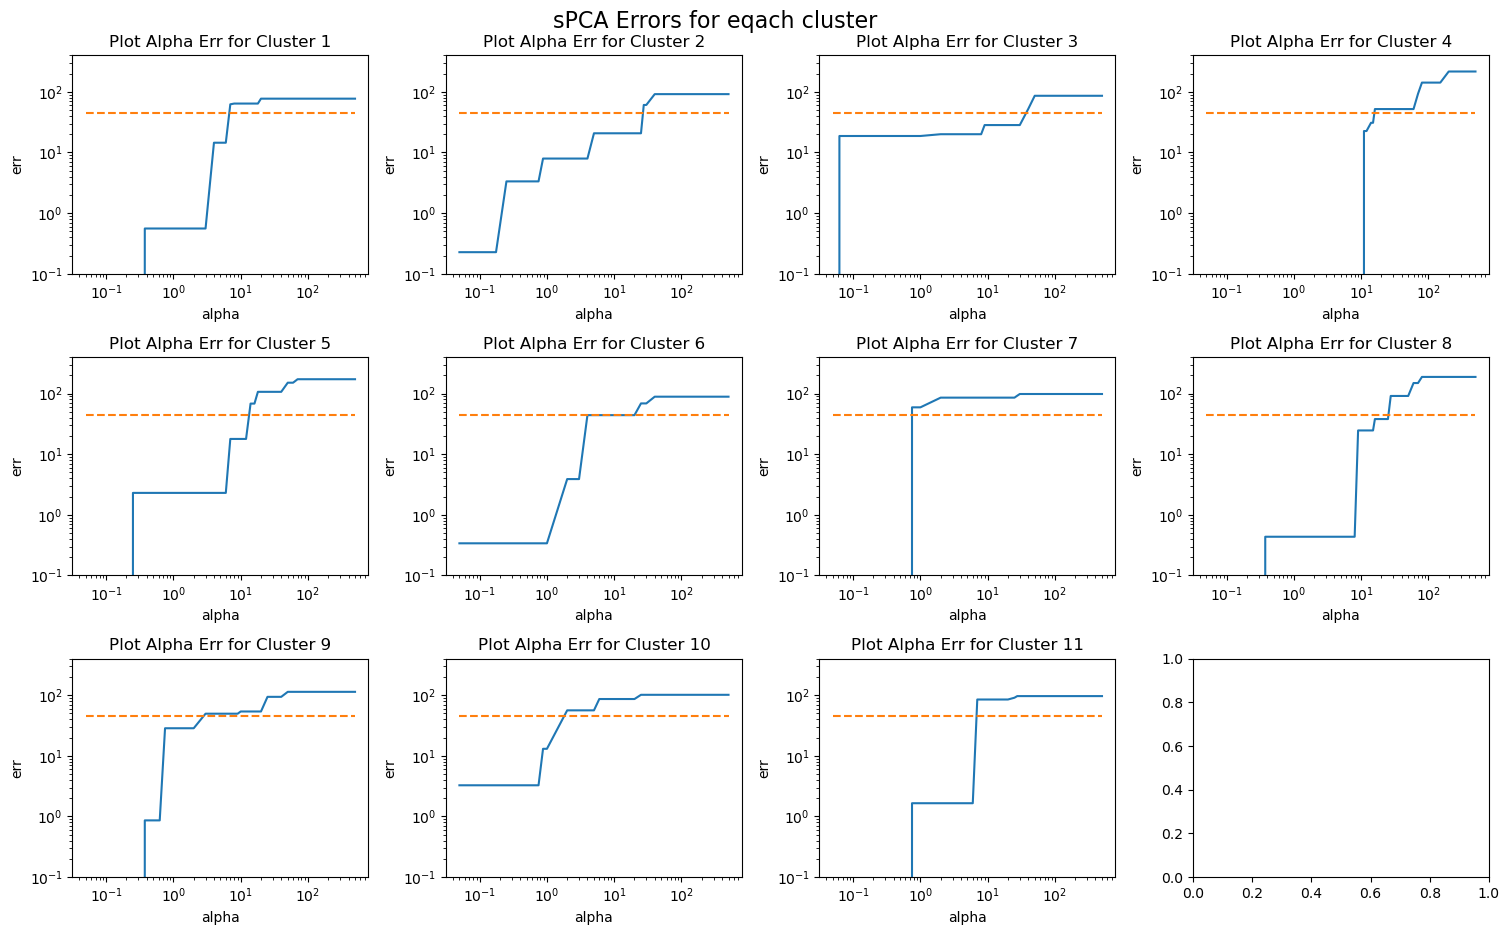

In [6]:
# Create figure and axes with 3x4 subplots, sharing the x-axis
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plotting
for i in range(nc):
    axes[i].loglog(alphas, cluster_err[i])
    axes[i].loglog(alphas, 45 * np.ones_like(np.array(alphas)), linestyle='--')
    axes[i].set_title(f'Plot Alpha Err for Cluster {i + 1}')
    # if i == 2:
    axes[i].set_ylim(0.1,400)
    axes[i].set_xlabel('alpha')
    axes[i].set_ylabel('err')

# # Add shared x-label and y-label
# fig.text(0.5, 0.04, 'X Axis', ha='center')
# fig.text(0.04, 0.5, 'Y Axis', va='center', rotation='vertical')

# Adjust layout
plt.tight_layout(rect=[0.05, 0.05, 1, 0.97])
plt.suptitle("sPCA Errors for eqach cluster", fontsize=16)
plt.show()

In [7]:
def train_sPCA_model_multi_alpha(opt_alpha_list, features, nfeatures, nc, cluster_idx):
    spca_model = np.zeros([nc, nfeatures])
    for i in range(nc):
        alpha_opt = opt_alpha_list[i]
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alpha_opt)
        spca.fit(cluster_features)
        # print('GMM Cluster {0}:'.format(i))
        active_terms = np.nonzero(spca.components_[0])[0]
        if len(active_terms)>0:
            # print([labels[k] for k in active_terms])
            spca_model[i, active_terms] = 1  # Set to 1 for active terms in model
        else: print('None')

    return spca_model

In [8]:

# err_threshold = 50
# err_threshold = 45
err_threshold = 45

alpha_opt = []
for i in range(nc):
    for j,err in enumerate(cluster_err[i]):
        if err > err_threshold:
            alpha_opt.append(alphas[j-1]) # append the last alpha value that was not above the error threshold
            break

print(alpha_opt)

[6, 25, 30, 15, 12, 20, 0.625, 25, 2, 1, 6]


In [9]:
optimal_alphas = alpha_opt

In [10]:
spca_model = train_sPCA_model_multi_alpha(optimal_alphas, features, nfeatures, nc, cluster_idx.flatten()-1)

In [11]:
balance_models, model_index = np.unique(spca_model, axis=0, return_inverse=True)

# print(balance_models)
nmodels = balance_models.shape[0]

balance_idx = np.array([model_index[i] for i in cluster_idx.flatten() - 1])

In [12]:
indices = []
for i in range(masked_y_coords_DNS_grid.size):
    if masked_y_coords_DNS_grid[i] < 0.6:
        indices.append(i)

In [13]:
np.sum(np.isnan(balance_idx[indices]))

0

In [14]:
cmap_white= cm.copy()
cmap_white.set_bad('white')

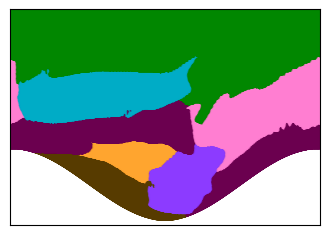

<Figure size 640x480 with 0 Axes>

In [17]:
# Save balance_model and balance maps & plot them too
fig = plt.figure(figsize = (4,2.8))
plt.scatter(masked_x_coords_DNS_grid[indices],masked_y_coords_DNS_grid[indices], 2, balance_idx[indices]+1, cmap = cmap_white, vmin=-0.5, vmax=cm.N-0.5)
# plt.colorbar(boundaries=np.arange(0.5, int(nmodels)+1.5), ticks=np.arange(1, int(nmodels)+2))
plt.gca().set_facecolor('white')
plt.gca().patch.set_alpha(1.0)
plt.xticks([])
plt.yticks([])
plt.xlim(np.min(masked_x_coords_DNS_grid[indices]),np.max(masked_x_coords_DNS_grid[indices]))
plt.ylim(0,np.max(masked_y_coords_DNS_grid[indices]))
# plt.savefig(save_dir + f'trial{i}/sPCA_ClusterDomain,nc{nc}')
# Transparent outside figure
fig.patch.set_alpha(0)
fig.patch.set_facecolor('none')
plt.savefig(f'sPCA_ClusterDomain_WW_DNS.png',dpi=480,bbox_inches='tight')
plt.show()
plt.clf()

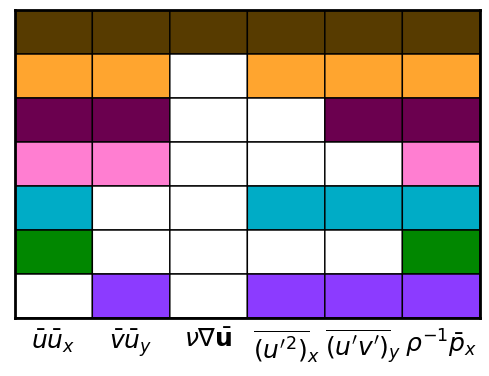

<Figure size 640x480 with 0 Axes>

In [18]:
# Plot a grid with active terms in each cluster
gridmap = balance_models.copy()
gridmask = gridmap==0
gridmap = (gridmap.T*np.arange(nmodels)).T+1  # Scale map so that active terms can be color-coded
gridmap[gridmask] = 0

grid_labels_pressure = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$',
                    r'$\nu \nabla \bar{\bf{u}}$', 
                    r'$\overline{({u^\prime} ^2)}_x$', r'$\overline{(u^\prime v^\prime)}_y$', r'$\rho^{-1} \bar{p}_x$']

gridmap_pressure = np.vstack([gridmap.T,gridmap[:,3]]).T[:,[0,1,2,4,5,6]]

plt.figure(figsize=(6, 4))
plt.pcolor(gridmap_pressure, vmin=-0.5, vmax=cm.N-0.5, cmap=cm_balance_models, edgecolors='k', linewidth=1)
plt.gca().set_xticks(np.arange(0.5, gridmap_pressure.shape[1]+0.5))
plt.gca().set_xticklabels(grid_labels_pressure, fontsize=18)
plt.gca().set_yticklabels([])

for axis in ['top','bottom','left','right']:
    plt.gca().spines[axis].set_linewidth(2)

plt.gca().tick_params(axis='both', width=0)

plt.savefig(f'sPCA_Matrix_Model_WW_DNS.png',bbox_inches='tight',transparent=True,dpi=480)
# plt.savefig(save_dir + f'trial{i}/sPCA_Matrix_Model')
plt.show()
plt.clf()

# save cluster_idx np array and spca_model np
# np.save(save_dir + f'trial{i}/spca_model.npy', balance_models)
# np.save(save_dir + f'trial{i}/cluster_idx.npy', balancemap)

Really good, only weird bit imo is the presence of both RS terms in cyan... 